In [1]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets, transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer


# ----------------------------
# Subset sampler
# ----------------------------
def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)

    # FashionMNIST는 train_labels ❌ → targets ⭕
    for idx, label in enumerate(dataset.targets):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


# ----------------------------
# Model init
# ----------------------------
def model_init(classes, class_to_idx):
    model = ViTForImageClassification.from_pretrained(
        "google/vit-base-patch16-224-in21k",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
    )
    return model


# ----------------------------
# Data collator
# ----------------------------
def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor(labels)
    return {"pixel_values": pixel_values, "labels": labels}


# ----------------------------
# Metrics
# ----------------------------
def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(
        predictions=predictions,
        references=labels,
        average="macro",
    )


# ----------------------------
# Dataset
# ----------------------------
train_dataset = datasets.FashionMNIST(
    root="../datasets", download=True, train=True
)
test_dataset = datasets.FashionMNIST(
    root="../datasets", download=True, train=False
)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=classes, max_len=100
)


# ----------------------------
# Image processor & transform
# ----------------------------
image_processor = AutoImageProcessor.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.Resize(
            (image_processor.size["height"], image_processor.size["width"])
        ),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # grayscale → RGB
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std,
        ),
    ]
)


# ----------------------------
# Training arguments
# ----------------------------
args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",   # evaluation_strategy ❌ → eval_strategy ⭕
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
)


# ----------------------------
# Trainer
# ----------------------------
trainer = Trainer(
    model_init=lambda _: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    # tokenizer=image_processor → Vision 모델에 불필요
)

trainer.train()

/Users/iwon-yong/.pyenv/versions/venv310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1045.97it/s, Materializing param=vit.layernorm.weight]                                
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISS

Epoch,Training Loss,Validation Loss,F1
1,0.695397,0.633908,0.889460
2,0.467822,0.466134,0.920408
3,0.405427,0.419796,0.924334


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]
/Users/iwon-yong/.pyenv/versions/venv310/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.14it/s]
/Users/iwon-yong/.pyenv/versions/venv310/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.53it/s]


TrainOutput(global_step=1875, training_loss=0.691433750406901, metrics={'train_runtime': 1203.9509, 'train_samples_per_second': 24.918, 'train_steps_per_second': 1.557, 'total_flos': 2.32492637712384e+18, 'train_loss': 0.691433750406901, 'epoch': 3.0})

/Users/iwon-yong/.pyenv/versions/venv310/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


PredictionOutput(predictions=array([[ 3.094325  , -0.54432297, -0.3143742 , ..., -0.5810334 ,
        -0.43139866, -0.5348758 ],
       [ 1.835083  , -0.44250828,  0.13530517, ..., -0.6356622 ,
        -0.69744533, -0.89922166],
       [ 3.0545735 , -0.5675716 , -0.23214178, ..., -0.5866174 ,
        -0.3567126 , -0.5321724 ],
       ...,
       [-0.6217276 , -0.66686815, -0.56022125, ...,  0.45926672,
         0.1236046 ,  2.9658167 ],
       [-0.42439196, -0.56524056, -0.44004646, ...,  0.14833227,
        -0.38001806,  3.3301437 ],
       [-0.30969736, -0.5903161 , -0.3861832 , ..., -0.28496724,
        -0.292627  ,  3.3121428 ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

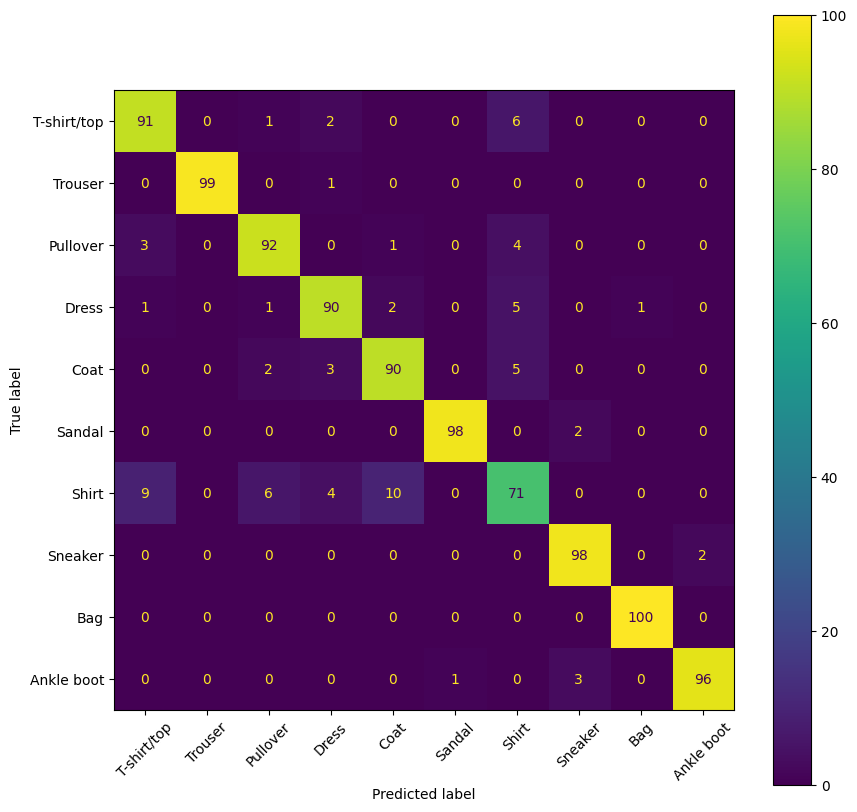

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()